In [ ]:
import fiesta
#from fiesta.surrogates import download_recommended_surrogates
#download_recommended_surrogates()

from survey_sim import DetectionCriteria

from survey_sim import FixedBu2026KilonovaPopulation, SimulationPipeline, load_ztf_survey
from survey_sim import Bu2026KilonovaPopulation
from survey_sim.fiesta_model import FiestaKNModel
from contextlib import redirect_stdout
import io
import math
# from fiesta.surrogates import download_recommended_surrogates; download_recommended_surrogates()

In [ ]:
import fiesta
# from fiesta.surrogates import download_recommended_surrogates
# download_recommended_surrogates()

[pipeline] Phase 1 spatial match: 3.0s, 63549 matched of 100000 generated
[pipeline] Phase 2 lightcurve eval: 5.8s, 63549 evaluations
[pipeline] Phase 3 detection: 0.4s


SimulationResult
  n_simulated: 100000
  n_detected:  3920
  efficiency:  0.0392
  sources:     2271
  rate_summaries:
    Kilonova : rate=1.000e3 Gpc^-3/yr, eff=0.0392, det/yr=2.741e2, det_total=2.741e3 (T=10.00 yr, omega=8.403e0 sr)

Kilonova: R_upper(90%) = 0.8 Gpc^-3 yr^-1
Kilonova: R_upper(95%) = 1.1 Gpc^-3 yr^-1
Kilonova: R_upper(99%) = 1.7 Gpc^-3 yr^-1


RuntimeError: latex was not able to process the following string:
b'Upper Limit (Gpc^-3 yr^-1)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode -halt-on-error -no-shell-escape file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
entering extended mode
(./file.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/fix-cm.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/ts1enc.def))
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty)
(/usr/share/texlive/te

<Figure size 640x480 with 1 Axes>

In [ ]:
from survey_sim.fiesta_model import FiestaKNModel

from survey_sim import (
    FixedBu2026KilonovaPopulation,
    DetectionCriteria,
    SimulationPipeline,
    load_ztf_survey,
)

survey = load_ztf_survey(nside=64)

kn_pop = FixedBu2026KilonovaPopulation(
    log10_mej_dyn=-1.8, v_ej_dyn=0.2, ye_dyn=0.15,
    log10_mej_wind=-1.1, v_ej_wind=0.1, ye_wind=0.35,
    inclination_em=0.45,
    rate=1000.0, z_max=0.3,
)

model = FiestaKNModel()

det = DetectionCriteria(min_detections=2, snr_threshold=5.0)

pipe = SimulationPipeline(
    survey,
    [kn_pop],
    {"Kilonova": model},
    det,
    n_transients=10000,
    seed=42,
)
result = pipe.run()
print(result)

survey = SurveyStore.from_rubin("baseline_v5.0.0_10yrs.db")

# Population: 1000 Gpc^-3 yr^-1, z < 0.3
kn_pop = KilonovaPopulation(rate=1000.0, z_max=0.3, peak_abs_mag=-16.0)

# Parametric lightcurve model (Rust-native, parallel)
model = MetzgerKNModel()

# At least 2 detections at 5-sigma
det = DetectionCriteria(min_detections=2, snr_threshold=5.0)

pipe = SimulationPipeline(
    survey,
    [kn_pop],
    {"Kilonova": model},
    det,
    n_transients=100_000,
    seed=42,
)
with redirect_stdout(io.StringIO()):
    result = pipe.run()
print(result)
for rs in result.rate_summaries:
      ul90 = rs.upper_limit(0.90)
      ul95 = rs.upper_limit(0.95)
      ul99 = rs.upper_limit(0.99)
      print(f"{rs.transient_type}: R_upper(90%) = {ul90.rate_upper:.1f} Gpc^-3 yr^-1")
      print(f"{rs.transient_type}: R_upper(95%) = {ul95.rate_upper:.1f} Gpc^-3 yr^-1")
      print(f"{rs.transient_type}: R_upper(99%) = {ul99.rate_upper:.1f} Gpc^-3 yr^-1")
      
      
## ecdf plot of the rs.upper_limit values. Iterate from 1 to 100 and plot the ecdf of the upper limits at each iteration. Use matplotlib to create the plot.
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import cumfreq
upper_limits = [rs.upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)]
# print(upper_limits)
ecdf = cumfreq(upper_limits, numbins=100)
x = ecdf.lowerlimit + np.arange(ecdf.cumcount.size) * ecdf.binsize
y = ecdf.cumcount / ecdf.cumcount[-1]
plt.plot(x, y, linewidth=3)
plt.xlabel('Upper Limit (Gpc^-3 yr^-1)')
plt.xscale('log')
plt.title('Cumulative Distribution of Upper Limits')
# plt.legend()
plt.grid(True, which='both')
plt.show()

ImportError: libhdf5.so.310: cannot open shared object file: No such file or directory

In [ ]:
dir(result)
from survey_sim.serialization import save_result, load_result

In [ ]:
save_result(result, "sim_result.json")

TypeError: cannot unpack non-iterable builtin_function_or_method object

In [ ]:
%%capture
survey = load_ztf_survey(nside=64);

: 

In [ ]:
# pop = FixedBu2026KilonovaPopulation(
#     log10_mej_dyn=-1.8, v_ej_dyn=0.2, ye_dyn=0.15,
#     log10_mej_wind=-1.1, v_ej_wind=0.1, ye_wind=0.35,
#     inclination_em=0.45,
#     rate=10.0, z_max=0.3,
# )

pop = Bu2026KilonovaPopulation(
    rate=100.0, z_max=0.3,
)
# model = MetzgerKNModel()

model = FiestaKNModel()

det = DetectionCriteria(
    snr_threshold=5.0, snr_threshold_secondary=3.0,
    min_detections=2, min_detections_primary=1,
    max_timespan_days=14.0, min_time_separation_hours=3.0,
    require_fast_transient=True, min_rise_rate=0.0, min_fade_rate=0.3,
    min_galactic_lat=15.0,
)

pipe = SimulationPipeline(survey, [pop], {"Kilonova": model}, det, n_transients=100_000, seed=42)
with redirect_stdout(io.StringIO()):
    result = pipe.run()
print(result)
for rs in result.rate_summaries:
      ul90 = rs.upper_limit(0.90)
      ul95 = rs.upper_limit(0.95)
      ul99 = rs.upper_limit(0.99)
      print(f"{rs.transient_type}: R_upper(90%) = {ul90.rate_upper:.1f} Gpc^-3 yr^-1")
      print(f"{rs.transient_type}: R_upper(95%) = {ul95.rate_upper:.1f} Gpc^-3 yr^-1")
      print(f"{rs.transient_type}: R_upper(99%) = {ul99.rate_upper:.1f} Gpc^-3 yr^-1")

15:16 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
15:16 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
15:16 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
15:16 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
15:16 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
15:16 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
15:16 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
15:16 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
15:16 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
15:16 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty'].
15:16 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /home/tbarna/fiestaEM/src/fiesta/surrogates/KN/Bu2026_MLP/model.
[pipeline] Phase 1 spatial match: 2.4s, 72588 matched of 100000 generated


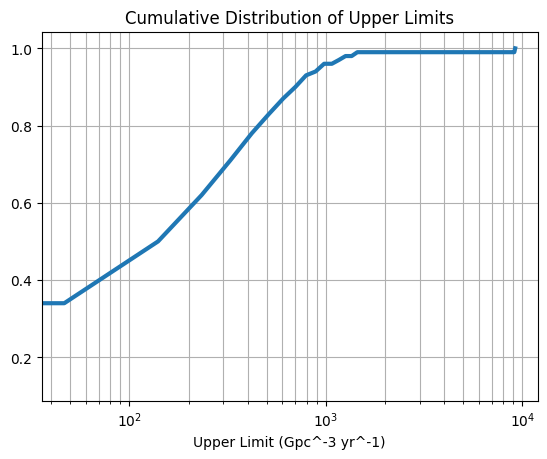

In [ ]:
## ecdf plot of the rs.upper_limit values. Iterate from 1 to 100 and plot the ecdf of the upper limits at each iteration. Use matplotlib to create the plot.
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import cumfreq
upper_limits = [rs.upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)]
# print(upper_limits)
ecdf = cumfreq(upper_limits, numbins=100)
x = ecdf.lowerlimit + np.arange(ecdf.cumcount.size) * ecdf.binsize
y = ecdf.cumcount / ecdf.cumcount[-1]
plt.plot(x, y, linewidth=3)
plt.xlabel('Upper Limit (Gpc^-3 yr^-1)')
plt.xscale('log')
plt.title('Cumulative Distribution of Upper Limits')
# plt.legend()
plt.grid(True, which='both')
plt.show()

In [ ]:
pop = FixedBu2026KilonovaPopulation(
    log10_mej_dyn=-1.8, v_ej_dyn=0.2, ye_dyn=0.15,
    log10_mej_wind=-1.1, v_ej_wind=0.1, ye_wind=0.35,
    inclination_em=0.45,
    rate=100, z_max=0.3,
)
model = FiestaKNModel()

pipe = SimulationPipeline(survey, [pop], {"Kilonova": model}, det, n_transients=100_000, seed=42)
with redirect_stdout(io.StringIO()):
    result = pipe.run()
print(result)
for rs in result.rate_summaries:
      ul90 = rs.upper_limit(0.90)
      ul95 = rs.upper_limit(0.95)
      ul99 = rs.upper_limit(0.99)
      print(f"{rs.transient_type}: R_upper(90%) = {ul90.rate_upper:.1f} Gpc^-3 yr^-1")
      print(f"{rs.transient_type}: R_upper(95%) = {ul95.rate_upper:.1f} Gpc^-3 yr^-1")
      print(f"{rs.transient_type}: R_upper(99%) = {ul99.rate_upper:.1f} Gpc^-3 yr^-1")

12:34 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
12:34 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
12:34 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
12:34 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
12:34 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
12:34 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
12:34 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
12:34 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
12:34 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
12:34 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty'].
12:34 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /home/tbarna/fiestaEM/src/fiesta/surrogates/KN/Bu2026_MLP/model.
[pipeline] Phase 1 spatial match: 1.6s, 72779 matched of 100000 generated
[pipeline] Phase 2 lightcurve e

SimulationResult
  n_simulated: 100000
  n_detected:  1
  efficiency:  0.0000
  sources:     1
  rate_summaries:
    Kilonova : rate=1.000e2 Gpc^-3/yr, eff=0.0000, det/yr=8.259e-3, det_total=6.612e-2 (T=8.01 yr, omega=8.219e0 sr)

Kilonova: R_upper(90%) = 3482.5 Gpc^-3 yr^-1
Kilonova: R_upper(95%) = 4530.9 Gpc^-3 yr^-1
Kilonova: R_upper(99%) = 6965.0 Gpc^-3 yr^-1


[pipeline] Phase 3 detection: 0.4s


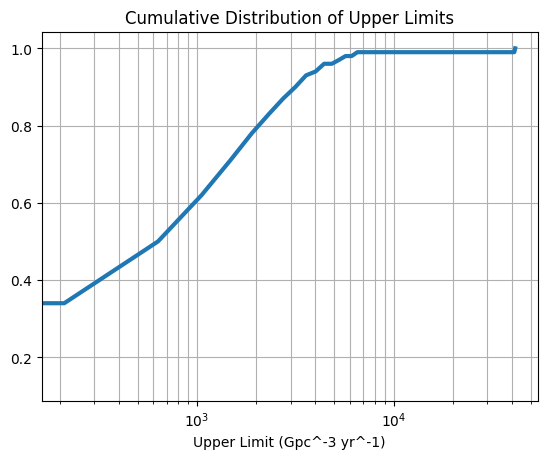

In [ ]:
## ecdf plot of the rs.upper_limit values. Iterate from 1 to 100 and plot the ecdf of the upper limits at each iteration. Use matplotlib to create the plot.
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import cumfreq
upper_limits = [rs.upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)]
# print(upper_limits)
ecdf = cumfreq(upper_limits, numbins=100)
x = ecdf.lowerlimit + np.arange(ecdf.cumcount.size) * ecdf.binsize
y = ecdf.cumcount / ecdf.cumcount[-1]
plt.plot(x, y, linewidth=3)
plt.xlabel('Upper Limit (Gpc^-3 yr^-1)')
plt.xscale('log')
plt.title('Cumulative Distribution of Upper Limits')
# plt.legend()
plt.grid(True, which='both')
plt.show()

In [ ]:
import math
survey = load_ztf_survey(nside=64)
print(f"  Observations: {survey.n_observations}")
print(f"  MJD range: {survey.mjd_range}")
print(f"  Duration: {survey.duration_years:.2f} years")
print(f"  Bands: {survey.bands}")

# Tuned AT2017gfo Bu2026 parameters (best g/r/i fit at t<4d)
# log10_mej_dyn=-1.8 (slightly less dynamical ejecta)
# inclination_em=0.45 rad (26 deg, consistent with GW170817 constraints)
pop = FixedBu2026KilonovaPopulation(
    log10_mej_dyn=-1.8,
    v_ej_dyn=0.2,
    ye_dyn=0.15,
    log10_mej_wind=-1.1,
    v_ej_wind=0.1,
    ye_wind=0.35,
    inclination_em=0.45,
    rate=1000.0,
    z_max=0.3,
)

# ZTFReST-like detection criteria
det = DetectionCriteria(
    snr_threshold=5.0,
    snr_threshold_secondary=3.0,
    min_detections=2,
    min_detections_primary=1,
    max_timespan_days=14.0,
    min_time_separation_hours=3.0,
    require_fast_transient=True,
    min_rise_rate=0.0,
    min_fade_rate=0.3,
    min_galactic_lat=15.0,
)

# Bu2026 model
model = FiestaKNModel()

# Run pipeline
N = 1000000
print(f"\nRunning pipeline with {N} transients (fixed incl=0.45 rad, tuned ejecta)...")
pipeline = SimulationPipeline(
    survey=survey,
    populations=[pop],
    models={"Kilonova": model},
    detection=det,
    n_transients=N,
    seed=42,
)
result = pipeline.run()
print(f"\nResults:")
print(f"  Simulated: {result.n_simulated}")
print(f"  Detected:  {result.n_detected}")
eff = result.n_detected / max(result.n_simulated, 1)
print(f"  Efficiency: {eff:.4f} ({eff*100:.2f}%)")

for rs in result.rate_summaries:
    print(f"\n  {rs.transient_type}:")
    print(f"    Volumetric rate: {rs.volumetric_rate:.1f} Gpc^-3/yr")
    print(f"    Overall efficiency: {rs.overall_efficiency:.4f}")

# Rate upper limits
duration = survey.duration_years
z_max = 0.3
d_max = 1380.0  # Mpc for z=0.3 approx
V_max = (4.0 / 3.0) * math.pi * (d_max / 1000.0) ** 3  # Gpc^3

# Sky coverage: ZTF covers ~47% of sky in public survey
omega_ztf = 0.47 * 4 * math.pi  # sr
f_sky = omega_ztf / (4 * math.pi)
V_eff = V_max * f_sky

VT_eff = V_eff * duration * eff

print(f"\n--- Rate Upper Limits ---")
print(f"  z_max = {z_max}, V_max = {V_max:.3f} Gpc^3")
print(f"  f_sky = {f_sky:.2f}, V_eff = {V_eff:.3f} Gpc^3")
print(f"  Duration = {duration:.2f} yr")
print(f"  Efficiency = {eff:.4f}")
print(f"  VT_eff = {VT_eff:.4f} Gpc^3 yr")

for cl, label in [(0.90, "90%"), (0.95, "95%")]:
    R_upper = -math.log(1 - cl) / VT_eff if VT_eff > 0 else float("inf")
    print(f"  R_upper ({label} CL) = {R_upper:.0f} Gpc^-3 yr^-1")


  ztf_201803.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201803.h5
  ztf_201804.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201804.h5
  ztf_201805.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201805.h5
  ztf_201806.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201806.h5
  ztf_201807.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201807.h5
  ztf_201808.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201808.h5
  ztf_201809.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201809.h5
  ztf_201810.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201810.h5
  ztf_201811.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201811.h5
  ztf_201812.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201812.h5
  ztf_201901.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201901.h5
  ztf_201902.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201902.h5
  ztf_201903.h5 -> /home/tbarna/.cache/survey-sim/ztf_boom/ztf_201903.h5
  ztf_201904.h5 -> /home/tbarna/.cache/survey-sim/z

15:12 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
15:12 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
15:12 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
15:12 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
15:12 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
15:12 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
15:12 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
15:12 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
15:12 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
15:12 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty'].
15:12 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /home/tbarna/fiestaEM/src/fiesta/surrogates/KN/Bu2026_MLP/model.


  Observations: 1293391
  MJD range: (58178.23087960016, 61102.31688660011)
  Duration: 8.01 years
  Bands: ['i', 'g', 'r']

Running pipeline with 1000000 transients (fixed incl=0.45 rad, tuned ejecta)...


: 